In [290]:
import copy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import gaussian_kde, linregress
from scipy.optimize import curve_fit

In [291]:
df = pd.read_csv(r"F:\Data\LiuDimer\WithWithout_C07\res.csv", sep=';')

In [292]:
df.keys()

Index(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn',
       'p1', 'p2', 'p1_folder', 'p2_folder', 'short_axis', 'long_axis',
       'p_xdir', 'p_ydir', 'cat', 'conf', 'w_px', 'h_px', 'grid_dist_x_nm',
       'grid_dist_y_nm', 'grid_period_x_nm', 'grid_period_y_nm',
       'on_grid_percentage', 'on_grid', 'mid_x_nm', 'mid_y_nm',
       'centroid_x_nm', 'centroid_y_nm', 'NN1_nm', 'NN2_nm', 'NN3_nm',
       'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm', 'span_y_nm',
       'span_long_axis_nm', 'span_short_axis_nm', 'long_axis_angle',
       'rect_angle', 'rect_width_nm', 'rect_height_nm', 'rect_area_nm',
       'rect_iou'],
      dtype='object')

In [293]:
df['img_fn']

0      C:\Users\seifert\Pictures\Temp\DataLib\compari...
1      C:\Users\seifert\Pictures\Temp\DataLib\compari...
2      C:\Users\seifert\Pictures\Temp\DataLib\compari...
3      C:\Users\seifert\Pictures\Temp\DataLib\compari...
4      C:\Users\seifert\Pictures\Temp\DataLib\compari...
                             ...                        
455    C:\Users\seifert\Pictures\Temp\DataLib\compari...
456    C:\Users\seifert\Pictures\Temp\DataLib\compari...
457    C:\Users\seifert\Pictures\Temp\DataLib\compari...
458    C:\Users\seifert\Pictures\Temp\DataLib\compari...
459    C:\Users\seifert\Pictures\Temp\DataLib\compari...
Name: img_fn, Length: 460, dtype: object

In [294]:
w_o = [1 if 'without' in x else 0 for x in df['img_fn']]

In [295]:
wth = [x for x in (np.ones_like(w_o) - np.array(w_o))]

In [296]:
df['with'] = wth

In [297]:
df['without'] = w_o

In [298]:
df['p1'] = wth

In [299]:
df['p2'] = w_o

In [300]:
confs = df['conf']

(array([ 5.,  6.,  9.,  4.,  2.,  3.,  5.,  4.,  4.,  2.,  5.,  3.,  4.,
         3.,  5.,  1.,  2.,  4.,  3.,  3.,  5.,  3.,  4.,  2.,  6.,  2.,
         2.,  5.,  3.,  4.,  6.,  4.,  1.,  3.,  4.,  4.,  1.,  5.,  2.,
         5.,  7.,  4.,  1.,  5.,  4.,  3.,  2.,  1.,  5.,  5.,  3., 11.,
         5.,  7.,  3.,  5.,  6.,  7.,  9.,  6.,  3., 10.,  6.,  7.,  9.,
        12.,  9., 10.,  4.,  8.,  9.,  4.,  7., 11.,  5.,  2.,  5.,  7.,
         6.,  9.,  9.,  4., 13.,  6.,  7.,  2.,  0.,  6.,  4.,  3.,  2.,
         1.,  1.,  0.,  3.,  3.,  4.,  1.,  0.,  1.]),
 array([0.700072  , 0.70216611, 0.70426022, 0.70635433, 0.70844844,
        0.71054255, 0.71263666, 0.71473077, 0.71682488, 0.71891899,
        0.7210131 , 0.72310721, 0.72520132, 0.72729543, 0.72938954,
        0.73148365, 0.73357776, 0.73567187, 0.73776598, 0.73986009,
        0.7419542 , 0.74404831, 0.74614242, 0.74823653, 0.75033064,
        0.75242475, 0.75451886, 0.75661297, 0.75870708, 0.76080119,
        0.7628953 , 0.7649

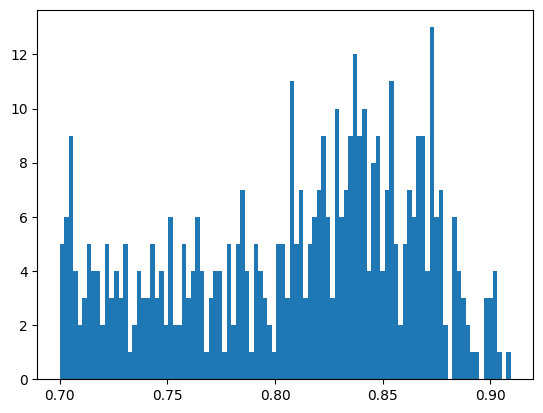

In [301]:
plt.hist(confs, bins=100)

# Number of High-Confidence Detections

In [302]:
conf_th = 0.7
df = df[df['conf'] > conf_th]
len(df)

460

# Correlation of important parameters

## With = 0 means "without", with=1 means "with"

In [303]:
df_corr = copy.deepcopy(df)
df_corr = df_corr.drop(['Unnamed: 0', 'total_id', 'p1_folder', 'p2_folder', 'img_id', 'crop_id', 'img_fn', 'crop_fn', 'short_axis', 'long_axis', 'p_xdir', 'p_ydir', 'cat', 'w_px', 'h_px', 'grid_dist_x_nm', 'grid_dist_y_nm',
       'grid_period_x_nm', 'grid_period_y_nm', 'on_grid_percentage', 'on_grid',
       'mid_x_nm', 'mid_y_nm', 'centroid_x_nm', 'centroid_y_nm', 'NN1_nm',
       'NN2_nm', 'NN3_nm', 'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm',
       'span_y_nm', 'span_long_axis_nm', 'span_short_axis_nm',
       'long_axis_angle',], axis=1)
print(df_corr.keys())
corr = df_corr.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.2f}')

Index(['p1', 'p2', 'conf', 'rect_angle', 'rect_width_nm', 'rect_height_nm',
       'rect_area_nm', 'rect_iou', 'with', 'without'],
      dtype='object')


,p1,p2,conf,rect_angle,rect_width_nm,rect_height_nm,rect_area_nm,rect_iou,with,without
p1,1.00,-1.00,0.43,-0.16,-0.11,-0.82,-0.64,0.29,1.00,-1.00
p2,-1.00,1.00,-0.43,0.16,0.11,0.82,0.64,-0.29,-1.00,1.00
conf,0.43,-0.43,1.00,-0.14,0.02,-0.28,-0.19,0.16,0.43,-0.43
rect_angle,-0.16,0.16,-0.14,1.00,-0.23,0.36,0.10,-0.28,-0.16,0.16
rect_width_nm,-0.11,0.11,0.02,-0.23,1.00,0.14,0.67,0.14,-0.11,0.11
rect_height_nm,-0.82,0.82,-0.28,0.36,0.14,1.00,0.79,-0.49,-0.82,0.82
rect_area_nm,-0.64,0.64,-0.19,0.10,0.67,0.79,1.00,-0.25,-0.64,0.64
rect_iou,0.29,-0.29,0.16,-0.28,0.14,-0.49,-0.25,1.00,0.29,-0.29
with,1.00,-1.00,0.43,-0.16,-0.11,-0.82,-0.64,0.29,1.00,-1.00
without,-1.00,1.00,-0.43,0.16,0.11,0.82,0.64,-0.29,-1.00,1.00


In [304]:
def linear_funct(x, intercept, slope):
    return intercept + x * slope

def linear_fit(x, y, dy=None):
    '''
    :return: intercept, gradient, d_inter, d_gradient
    '''
    with open('outf3.csv', 'w') as f:
        for a, b, c in zip(x, y, dy):
            f.write(f"{a};{b};{c}")
    a_fit,cov=curve_fit(linear_funct ,x ,y ,sigma=dy, absolute_sigma=True)
    return a_fit[0], a_fit[1], np.sqrt(cov[0][0]), np.sqrt(cov[1][1])

def density_plot(x, y, xlbl=None, ylbl=None):
    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

def density_plot_spacing(x, y, xpts, xspans=None, xlbl=None, ylbl=None):

    pts_x = []
    pts_y = []
    unc_y = []
    for i, xp in enumerate(xpts):
        if i == 0:
            xlim_min = -np.inf
            xlim_max = (xpts[0] + xpts[1])/2
        elif i == len(xpts)-1:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = np.inf
        else:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = (xpts[i+1] + xpts[i])/2

        locvals = []
        for xval, yval in zip(x, y):
            if xlim_min < xval < xlim_max:
                locvals.append(yval)

        if len(locvals) > 0:
            pts_x.append(xp)
            pts_y.append(np.median(locvals))
            unc_y.append(np.sqrt(np.pi * (2 * len(locvals) + 1) / (4 * len(locvals))) * np.std(locvals) / np.sqrt(len(locvals)))


    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

    ax.plot(pts_x, pts_y, c='red', label='median')
    ax.scatter(pts_x, pts_y, c='red', marker='x', s=50)
    ax.errorbar(pts_x, pts_y, yerr=unc_y, c='red')

    plt.legend()

def histo_evolution(x, y, xpts, xspans=None, xlbl=None, ylbl=None, bins=200):

    fig, ax = plt.subplots()
    keypts_x = []
    keypts_y = []
    kpy_sig = []

    mind = np.amin([abs(xpts[i] - xpts[i+1]) for i in range(len(xpts) - 1)])

    for i, xp in enumerate(xpts):
        if xspans is None:
            if i == 0:
                xlim_min = -np.inf
                xlim_max = (xpts[0] + xpts[1])/2
            elif i == len(xpts)-1:
                xlim_min = (xpts[i-1] + xpts[i])/2
                xlim_max = np.inf
            else:
                xlim_min = (xpts[i-1] + xpts[i])/2
                xlim_max = (xpts[i+1] + xpts[i])/2
        else:
            xlim_min = xp - xspans
            xlim_max = xp + xspans

        locvals = []
        for xval, yval in zip(x, y):
            if xlim_min < xval < xlim_max:
                locvals.append(yval)

        # print(locvals)
        if len(locvals) > 0:
            loc_hist = np.histogram(locvals, bins=bins)
            # print(loc_hist)
            histo_y = np.array(loc_hist[0], dtype=float)
            histo_x = np.array([(loc_hist[1][i] + loc_hist[1][i+1])/2 for i in range(len(loc_hist[1])-1)])
            histo_y/=np.amax(histo_y)
            histo_y *= mind
            histo_y += xp
            midpoint = np.median(locvals)
            keypts_x.append(midpoint)
            keypts_y.append(xp)
            n = len(locvals)
            kpy_sig.append(np.std(locvals) * np.sqrt(np.pi * (2*n+1) / (4*n)) / np.sqrt(n))
            # kpy_sig.append(np.std(locvals))
            ax.axhline(y=xp, c='gray', ls='--', alpha=0.8, lw=1)
            ax.plot(histo_x, histo_y, label=str(xp))
            ax.scatter([midpoint], [xp], marker='x', c='black', s=50)
            ax.errorbar([midpoint], [xp], xerr=kpy_sig[-1], marker='x', c='black')

    ax.set_xlabel(ylbl)
    ax.set_ylabel(xlbl)
    ax.plot(keypts_x, keypts_y, c='black', ls='--', lw=2)

    plt.legend(title=xlbl)
    with open('out2.csv', 'w') as f:
        for x, y, s in zip(keypts_x, keypts_y, kpy_sig):
            f.write(f'{y};{x};{s}\n')
    return keypts_y, keypts_x, kpy_sig

def histo_and_fit(x, y, xpts, xspans=None, xlbl=None, ylbl=None, bins=200, show_span=True):
    med_x, med_y, sig_y = histo_evolution(x, y, xpts, xspans, xlbl, ylbl, bins)
    plt.show()
    plt.scatter(med_x, med_y)
    plt.errorbar(med_x, med_y, yerr=sig_y)
    plt.xlabel(xlbl)
    plt.ylabel(ylbl)

    med_x = np.array(med_x)
    med_y = np.array(med_y)
    sig_y = np.array(sig_y)

    # print(med_x.shape, med_x)
    # print(med_y.shape, med_y)
    # print(sig_y.shape, sig_y)
    res = linear_fit(med_x, med_y, sig_y)

    intercept = res[0]
    slope = res[1]
    d_intercept = res[2]
    d_slope = res[3]


    xs = np.linspace(min(med_x), max(med_x), 20)
    ys = [intercept + slope * x for x in xs]
    ys_max = [intercept + d_intercept + max( (slope + d_slope) * x, (slope - d_slope) * x) for x in xs]
    ys_min = [intercept - d_intercept + min( (slope + d_slope) * x, (slope - d_slope) * x) for x in xs]

    plt.plot(xs, ys)
    plt.plot(xs, ys_max, lw=1, c='gray', ls='--')
    plt.plot(xs, ys_min, lw=1, c='gray', ls='--')

    plt.title(f"({slope:.3f} $\pm$ {d_slope:.3f})x + ({intercept:.3f} $\pm$ {d_intercept:.3f})")

# Width and Height of Rectangles

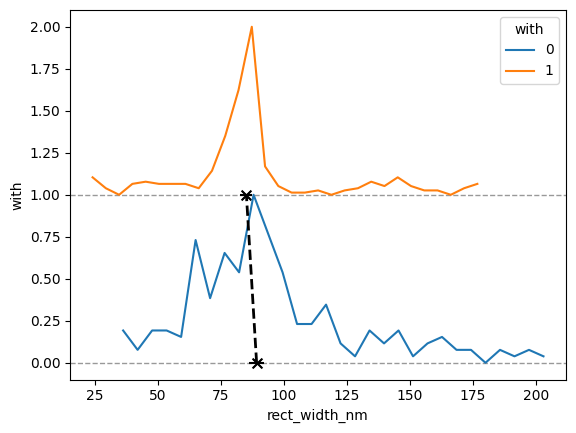

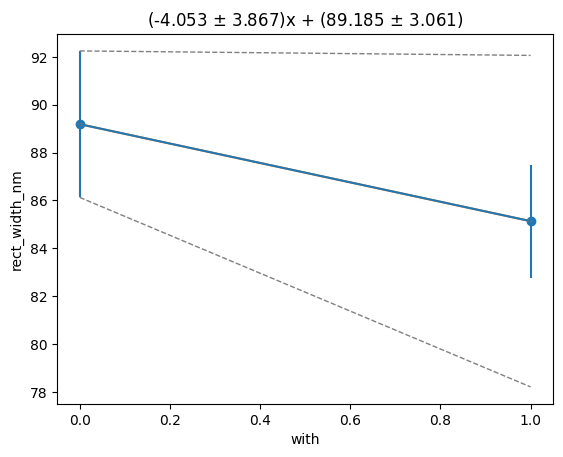

In [305]:
histo_and_fit(df['with'], df['rect_width_nm'], xpts=[0, 1], xlbl='with', ylbl='rect_width_nm', bins=30)

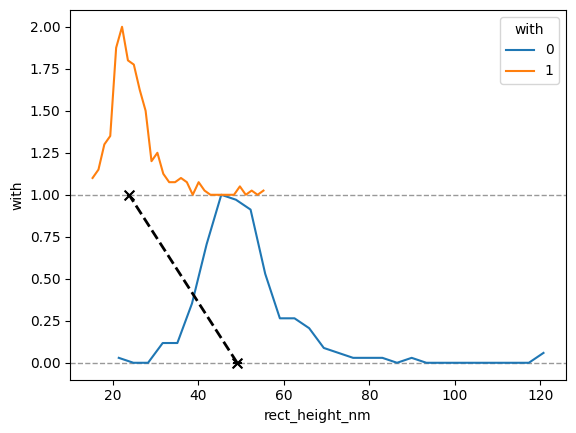

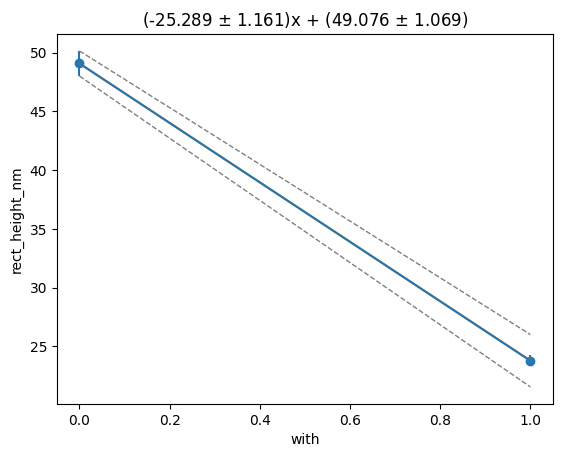

In [306]:
histo_and_fit(df['with'], df['rect_height_nm'], xpts=[0, 1], xlbl='with', ylbl='rect_height_nm', bins=30)


In [307]:
def write_cat_csvs(df, resfld, conf_th=0.7):
    prime1 = 389
    prime2 = 13003
    print(df.keys())
    os.makedirs(resfld, exist_ok=True)
    dicts = {}
    for i in range(len(df['total_id'])):
        if df['conf'][i] < conf_th:
            continue
        magic = 'with' if df['with'][i] == 1 else 'without'
        if magic not in dicts.keys():
            dicts[magic] = {'file': [],
                            'with': [],
                            'without': [],
                            'conf': [],
                            'span_x_nm': [],
                            'span_y_nm': [],
                            'rect_x_nm': [],
                            'rect_y_nm': []}
        dicts[magic]['file'].append(df['img_fn'][i])
        dicts[magic]['with'].append(df['with'][i])
        dicts[magic]['without'].append(df['without'][i])
        dicts[magic]['conf'].append(df['conf'][i])
        dicts[magic]['span_x_nm'].append(df['span_x_nm'][i])
        dicts[magic]['span_y_nm'].append(df['span_y_nm'][i])
        dicts[magic]['rect_x_nm'].append(df['rect_width_nm'][i])
        dicts[magic]['rect_y_nm'].append(df['rect_height_nm'][i])

    for k in dicts.keys():
        fn = os.path.join(resfld, f'{k}.csv')
        pd.DataFrame(dicts[k]).to_csv(fn, sep=';')

In [308]:
write_cat_csvs(df, r"F:\Data\LiuDimer\WithWithout_C07\csvs")

Index(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn',
       'p1', 'p2', 'p1_folder', 'p2_folder', 'short_axis', 'long_axis',
       'p_xdir', 'p_ydir', 'cat', 'conf', 'w_px', 'h_px', 'grid_dist_x_nm',
       'grid_dist_y_nm', 'grid_period_x_nm', 'grid_period_y_nm',
       'on_grid_percentage', 'on_grid', 'mid_x_nm', 'mid_y_nm',
       'centroid_x_nm', 'centroid_y_nm', 'NN1_nm', 'NN2_nm', 'NN3_nm',
       'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm', 'span_y_nm',
       'span_long_axis_nm', 'span_short_axis_nm', 'long_axis_angle',
       'rect_angle', 'rect_width_nm', 'rect_height_nm', 'rect_area_nm',
       'rect_iou', 'with', 'without'],
      dtype='object')
